# Tutorial 1 — optimizing an ADI reduction of β Pictoris (VLT/NACO L′)

**klip-tpe** searches the parameter space of a KLIP/ADI reduction (KL modes, temporal
binning, high-pass filter, azimuthal zones, reference exclusion angles, frame selection,
which nights/groups to combine) with a Tree-structured Parzen Estimator, scoring every
trial by the S/N of fake companions injected at fresh random positions, then
*validates* the best candidates on independent injections so the winner is not a lucky
draw.  It is the Python port of the optimizer used for the NEAR/VISIR and LBTI/NOMIC
mid-infrared campaigns, with the same live display and product set.

This notebook runs the whole pipeline on a small public data set — the VIP tutorial
sequence of β Pictoris (NACO L′, 61 frames, 101×101 px, Absil et al. 2013), which contains
the planet β Pic b at ~0.45″.  The search in section 4 is ~900 reductions: about five
minutes of computation on one core, and 10–20 minutes in practice because it **draws a
live panel while it runs**.  Watch that panel — section 4 says what to look for, and
section 3 says why the budget is the size it is.

```
pip install "klip-tpe[plots]"          # or: pip install -e ".[plots]" from a clone
```
Everything below also works from a terminal (`klip-tpe generic ...`) — see the last section.

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay

RUN_DIR = os.path.abspath("runs/betapic_naco")      # everything the run produces goes here
# Re-running this notebook RESUMES that directory: a finished annulus is reported complete
# in 0.0 min and no new panels are drawn.  Delete runs/betapic_naco to search again.

## 1. The data

`klip_tpe.datasets.fetch` downloads (once, into `~/.klip_tpe/data`) the three files of
the VIP data set: the registered cube, the derotation angles and an unsaturated PSF.

In [2]:
files = datasets.fetch("naco_betapic")
files

{'cube': '/root/.klip_tpe/data/naco_betapic_cube_cen.fits',
 'angles': '/root/.klip_tpe/data/naco_betapic_derot_angles.fits',
 'psf': '/root/.klip_tpe/data/naco_betapic_psf.fits'}

(61, 101, 101) (61,) (39, 39) field rotation 81.4 deg


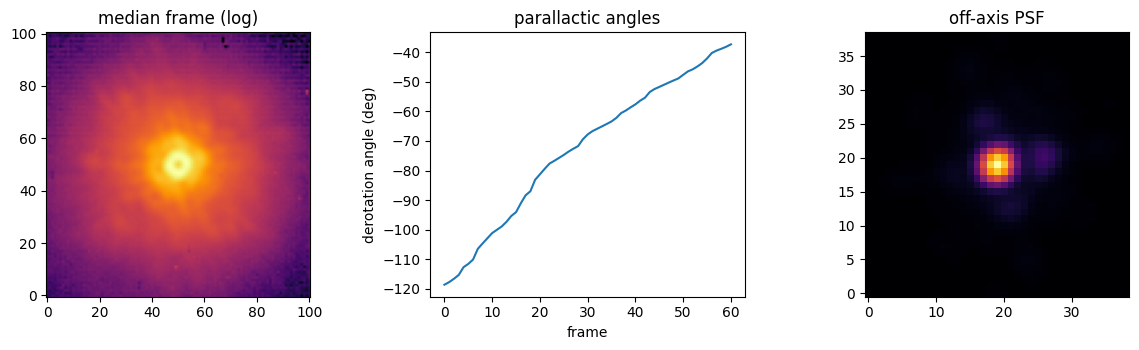

In [3]:
cube = fits.getdata(files["cube"]); angles = fits.getdata(files["angles"]); psf = fits.getdata(files["psf"])
print(cube.shape, angles.shape, psf.shape, f"field rotation {np.ptp(angles):.1f} deg")
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(np.log10(np.clip(np.nanmedian(cube, 0), 1, None)), origin="lower", cmap="inferno"); ax[0].set_title("median frame (log)")
ax[1].plot(angles); ax[1].set_xlabel("frame"); ax[1].set_ylabel("derotation angle (deg)"); ax[1].set_title("parallactic angles")
ax[2].imshow(psf, origin="lower", cmap="inferno"); ax[2].set_title("off-axis PSF")
plt.tight_layout()

## 2. Dataset → reducer → search space

The *generic* adapter takes any registered cube.  Three conventions matter:

* **angles** – klip-tpe derotates each frame counter-clockwise by `angle` (same sign as
  VIP's `angle_list` / pyKLIP's `PAs`); use `angle_sign=-1` for the opposite convention.
* **star flux** – injected companions are expressed as a *contrast*, so an absolute
  contrast axis needs the star's flux **in the science frames' own units and in the
  template's normalisation aperture**.  Neither of these two files carries it.  The science
  frames are AGPM coronagraphic (the radial profile is suppressed inside ~3 px — the star
  is occulted, not saturated), so you cannot read the star off them; and the distributed
  `naco_betapic_psf.fits` is a *normalised* template — its flux inside r = 2.000 px is
  1.000000000 — so its counts are not β Pictoris either.  Leave `star_flux` unset and
  `TemplatePSF` falls back to the stamp's own sum, 4.349, which puts the "contrast" axis a
  factor of 9.4 × 10⁵ away from a contrast.  A normalised template is the easiest way to
  get a plausible-looking axis that means nothing.

  What is needed is photometry the *observer* made.  `datasets.PHOTOMETRY` carries VIP's
  published `starphot = 764939.6` for this very cube — measured on the non-coronagraphic
  PSF and rescaled to the coronagraphic integration time, in the same 2 px aperture the
  template is normalised in — and `star_flux_from_aperture_photometry` converts it into the
  normalisation `TemplatePSF` uses.  **And then it gets checked**: with that star flux,
  β Pic b measures ΔL′ = 7.81 ± 0.08 against the 8.01 ± 0.16 that Absil et al. (2013)
  published from these same data — 1.1 σ.  `scripts/check_betapic_contrast.py` is that
  measurement; run it if you change anything upstream of the axis.

  A `star_flux_from_halo` helper used to stand here instead, scaling the template to the
  science halo at 6–14 px.  It has been removed: fitting an off-axis template to a
  *coronagraphic* halo compares two different functions, and it showed — the same method on
  the same data returned fluxes 5.28× and 8.04× apart on paper runs A2 and B2, and both were
  wrong.  Use photometry, or say "template units" and mean it.
* **frame-quality tags** – the searched frame-selection thresholds (`corr_thresh`,
  `noise_max`, `coronoise_max`) act on per-frame tags.  When the data bring none, the
  adapter derives them from the cube itself (`quality_tags`).

`INSTRUMENT` holds the plate scale, wavelength and aperture (λ/D = 3.5 px here).

`make_space` scales the parameter ranges to *these* data: KL modes up to `nframes/5`,
and temporal binning up to `nframes/8` frames per bin so that at least eight bins — and
therefore enough KLIP references — always survive.  (The NEAR production range is 5–30
frames per bin; on a 61-frame cube that would leave two bins and no real subtraction.
`bin_range=(lo, hi)` sets it by hand.)

In [4]:
inst = datasets.INSTRUMENT["naco_betapic"]
ds = generic.load_cube(files["cube"], files["angles"], psf=files["psf"], name="betapic")
print(f"tags: {list(ds.tags)}")

phot = datasets.PHOTOMETRY["naco_betapic"]
star_flux = generic.star_flux_from_aperture_photometry(psf, phot["starphot"], phot["aperture_px"])
print(f"template sum {psf.sum():.4f}, flux in r={phot['aperture_px']} px "
      f"{generic.aperture_sum(psf, 19, 19, phot['aperture_px']):.9f} -> star_flux {star_flux:.4g}")

red = generic.make_reducer({"betapic": ds}, star_flux=star_flux, max_workers="auto", **inst)
space = generic.make_space(red, k_klip_max=30)      # 61 frames -> <=30 KL modes, <=7 frames per temporal bin
space.project = generic.make_guard(red, k_max=30)   # feasibility: enough references per frame etc.
objective, sampler = generic.default_config(red, known=[(0.452, 211.9)])   # keep injections away from beta Pic b
print(space.names)

tags: ['corrs', 'noises', 'coronoise']
template sum 4.3491, flux in r=2.0 px 0.999999998 -> star_flux 3.327e+06
  betapic: 61 frames 101x101 px, PA span 81.4 deg, injection template (flux unit 3.33e+06), fwhm 3.61 px, lambda/D 3.52 px
['bin', 'n_ang', 'filter', 'angsep', 'anglemax', 'corr_thresh', 'noise_max', 'coronoise_max', 'k_klip']


A single reduction with the default parameters (0.3 s) already shows β Pic b at the
expected place (0.452″, PA 211.9°):

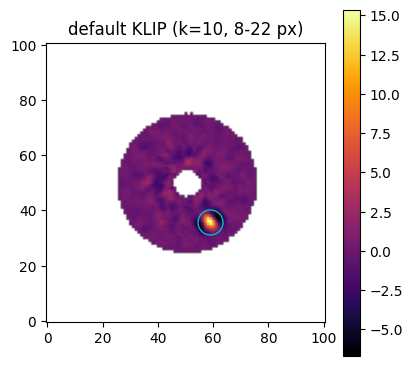

In [5]:
from klip_tpe.reducer import ReductionRequest
cfg0 = space.decode(space.default_vector())
res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=22, k_klip=10)))
rho_px = 0.452 / inst["pxscale"]; pa = np.deg2rad(211.9)
xb, yb = 50 - rho_px * np.sin(pa), 50 + rho_px * np.cos(pa)
plt.figure(figsize=(4.5, 4.5)); plt.imshow(res.image, origin="lower", cmap="inferno"); plt.plot(xb, yb, "o", mfc="none", mec="c", ms=18)
plt.title("default KLIP (k=10, 8-22 px)"); plt.colorbar();

## 3. Configure the optimization — and how big a budget it needs

**The annulus is where the optimization happens.**  Companions are injected at the
area-weighted mid radius of the annulus — √((8² + 22²)/2) = 16.6 px = 0.45″ here, i.e. at
β Pic b's separation, so the parameters are tuned for the region we care about.  A wider
annulus tunes for its own mid radius, which may be nowhere near your target.

The injection contrast is *calibrated* automatically so that the default configuration
detects the fakes at S/N ≈ 5 (parameters matter most where the companion is marginal);
`CalibrationConfig(forced=[c])` fixes it instead.

### The budget is not a free parameter

A run spends evaluations in three phases, and each one has a size it has to reach before
it does anything.  These numbers were **measured** on this exact data set and space — four
1200-evaluation searches plus eight 300-evaluation searches; [docs/BUDGET.md](
../docs/BUDGET.md) has the full tables and how to size a budget for your own data.

* **Warm-up, `n_init=40`.**  Random draws that give TPE something to model.  It sorts the
  history and fits a density to the best quarter, so `n_init=15` (this tutorial's old
  value) leaves *four* points to describe the nine dimensions below — measurably worse
  (true S/N 6.73) than 40, 100 or 200, which all land at 7.05–7.15.
* **Search, `n_iter=300`.**  The quality of the answer climbs steeply to ~100–120
  evaluations and is flat after that.  At 20 evaluations — where it is tempting to give
  up — the configuration you would take away is worth S/N ≈ 6.4 against the ≈ 7.6 this
  search reaches.  300 clears the plateau with margin.
* **Validation, `n_top=6, n_valid=8`.**  Re-scores the six best *distinct* configurations
  on eight fresh injection sets each and reports the median.  This is not a formality: the
  best score a search has *seen* is optimistic by **+1.5 S/N** at this budget, because the
  maximum of many noisy draws is high partly by luck.  Across twelve runs, the
  configuration the search ranked first was the truly-best of its own top eight in *none*
  of them.

`n_remeasure=3` is the other half of the story.  Scoring the same configuration twice does
not give the same number — the injection positions are redrawn every time, and on these
data that scatter is σ ≈ 0.87 S/N against a landscape only 1.44 wide.  Averaging three
draws per trial divides it by √3 and roughly halves the optimism above.  It costs 3×, and
it is worth it.

The whole thing is ~900 reductions.  Headless that is about **five minutes on one core**
(3–7 min across our runs; the optimizer drifts toward more expensive configurations as it
converges, so the second half is slower than the first), and `max_workers="auto"` above
already gave the reducer every core you have.  Drawing the live panel costs real CPU on
top of that — on a single core it dominated, taking 60 evaluations from 43 s to 290 s —
so the cell below throttles it to every second evaluation.  Raise `every` if the run
feels slow, or set `show=False` to keep the PNGs without the window.  The run logs a note
if the panel cannot keep up and starts skipping frames; that is the display protecting the
run, not a problem, and `klip-tpe render --run-dir ...` draws the missing ones afterwards.

In [6]:
cfg = RunConfig(ann_edges=[8, 22], n_iter=300, n_init=40, seed=1, n_remeasure=3,
                validation=ValidationConfig(n_top=6, n_valid=8),
                calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                defaults={"k_klip": 10}, fm_curve=True)

## 4. Run with the live display

**Watch the panel while this runs.**  `LiveDisplay(show="auto")` draws it inline in this
output cell inside Jupyter, and opens a matplotlib window when you run this file as a
script.  It is the only way to tell a converging search from a stuck one, and without it
the next five minutes are a silent process.  If you see nothing, the panel is also written
to `runs/betapic_naco/steps/stepNNNN.png` after every evaluation, and
`klip-tpe view --run-dir runs/betapic_naco` opens a window on a run that is already going
(from another terminal, read-only, attach and detach freely).

What you are looking at, and when it starts to mean something:

* **Calibration** (before evaluation 1).  A few reductions to set the injection contrast
  so the *default* parameters land at S/N ≈ 5.  The panel shows images but no trace yet.
* **Warm-up, evaluations 1–40.**  Random draws.  The convergence trace jumps around and
  the running best rises in occasional steps.  *Nothing is being learned yet* — this is
  the sample TPE will model.  A search stopped here has told you nothing.
* **Search, evaluations 41–300.**  TPE takes over.  The scatter of the trace tightens
  around good values and the S/N histogram shifts right; the running best rises in ever
  smaller steps and is roughly flat after ~120.  Each point carries an error bar (the
  spread of its three draws) — when the bars are as tall as the gaps between points, the
  ranking you are looking at is mostly noise, which is the normal state of affairs.
* **Validation, after evaluation 300.**  Six candidates × eight fresh injection sets.
  The trace stops growing and the validation trials appear; the winner is picked here.

The same PNGs go to `steps/`, a progress movie is rebuilt every 10 evaluations
(`annulus01/progress.gif`), and the books (corner, importance, landscapes, products,
verification) are written at the end of the annulus.

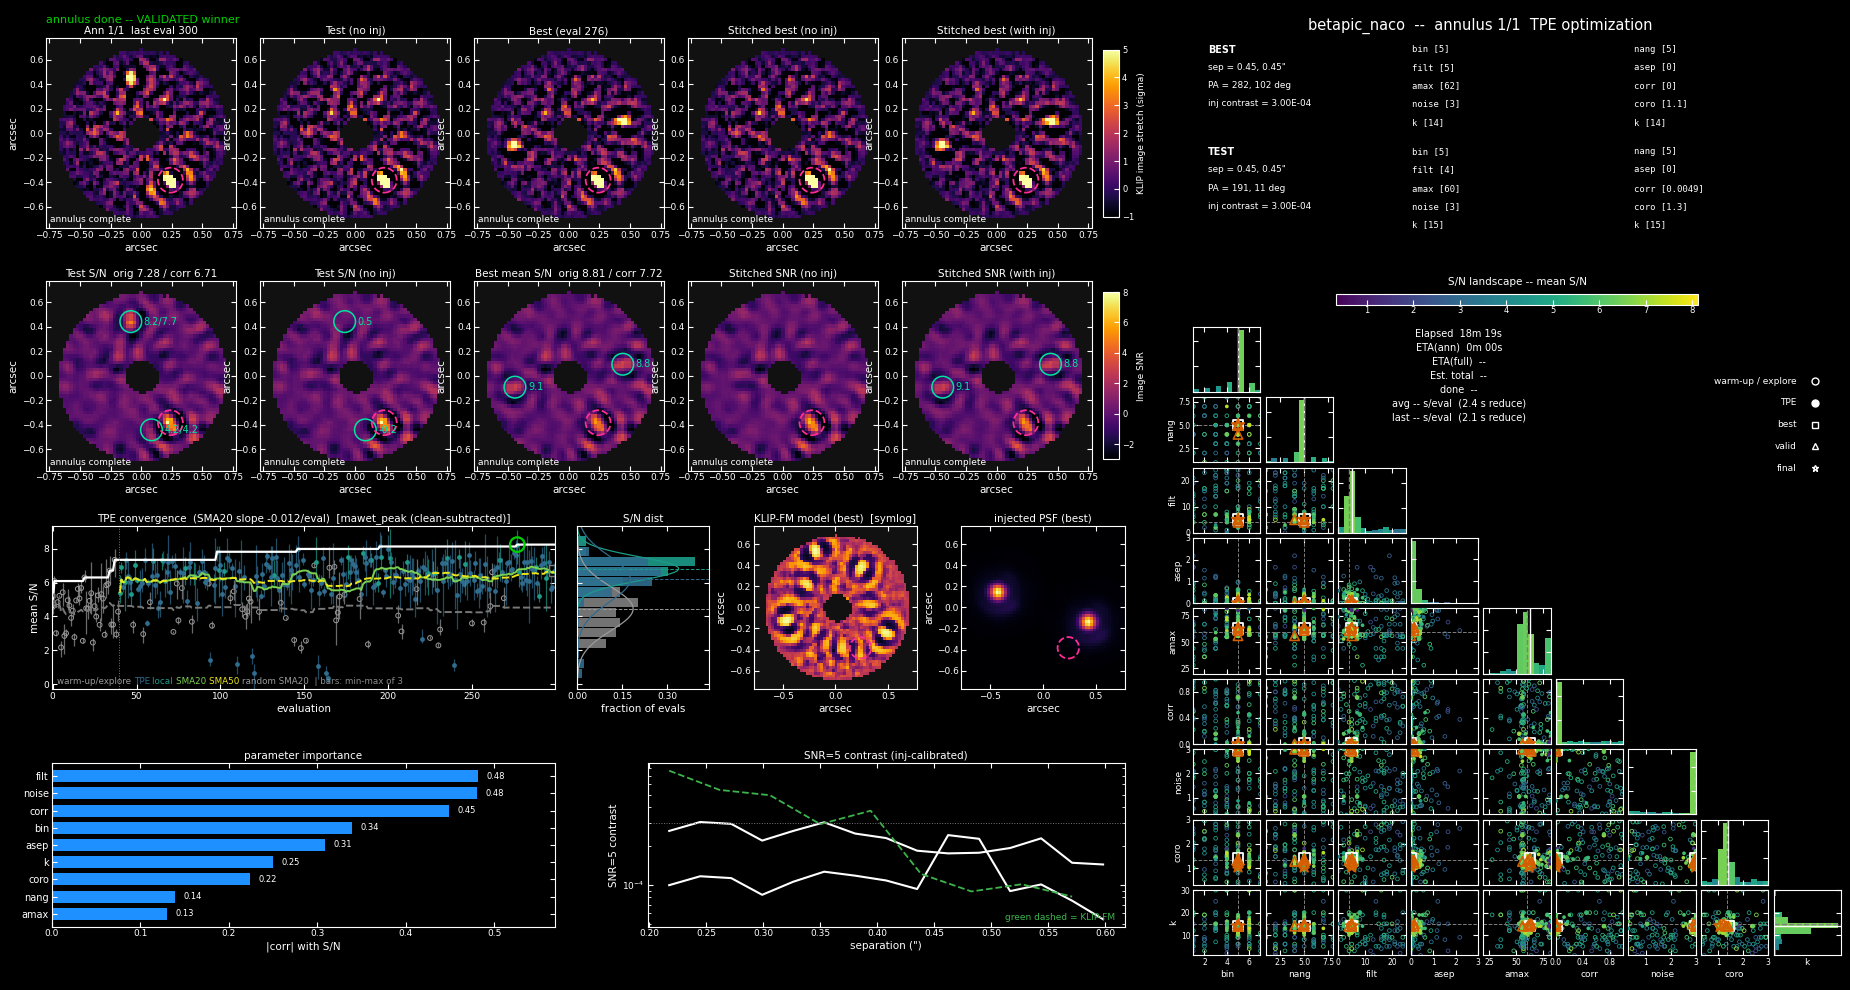

=== annulus 1/1: [8.0, 22.0] px, 2 sources, band 0.450-0.450"


  calibration trial 1: contrast=3.000e-05  k=10  median S/N=0.21


  calibration trial 2: contrast=3.000e-04  k=10  median S/N=4.25


  calibration k-scan at contrast 3.000e-04: k_default = 11 (S/N 6.12; k = 10 scores 5.46)
  calibration k-scan: keeping k = 10 -- k = 11 beats it by 0.660 in S/N, inside the 1.175 spread between the 2 draws, so the argmax is not resolved


[ann 1]   draw 1/3 score=4.163  (0s)
[ann 1]   draw 2/3 score=5.026  (0s)


...

param_verify config 19/20 (eval 68, score 6.07)


param_verify config 20/20 (eval 47, score 6.01)


param_verify annulus 01: 20 configs; combine K~7.792E+03


run complete: 1 annuli, 300 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.mp4']
done in 19.4 min


In [7]:
display = LiveDisplay(RUN_DIR, show="auto", window_scale=0.55, movie_every=10, every=2)
runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
t0 = time.time()
results = runner.run()
print(f"done in {(time.time() - t0) / 60:.1f} min")

## 5. Results

`results` holds one `AnnulusResult` per annulus; the same numbers are in
`final_results.json`, `annulus01/winner.json` and the human-readable `results.txt`.

**Quote the validated score, not the search best**, and do not read the two as the same
number changing.  They are different statistics: the search maximises
`s_inj − max(s_clean, 0)`, a one-sided speckle penalty at each injection site, while
validation deliberately reports the raw `s_inj`.  On these data that penalty is worth
+0.84 S/N, so validation sits ~0.8 *above* the search scale for the same configuration —
while the reported search maximum sits ~1.5 *above* the truth.  The two biases largely
cancel, which is why "search best → validated" often looks like a small, meaningless
change.  Compare search scores only with search scores.

In [8]:
r = results[0]
print(f"search best: eval {r.search_best_index + 1}, S/N {r.search_best_score:.2f}")
print(f"winner:      eval {r.winner_index + 1}, validated {r.validated}, validation median S/N {r.winner_score:.2f}")
print("winner parameters:", {k: v for k, v in r.winner_config['params'].items() if k in space.names})
print("validation table (candidate, trials):")
for row in r.validation_table:
    print(f"   eval {row['eval_index'] + 1}: search S/N {row['search_score']:.2f} -> validation trials "
          f"{np.round(row['trials'], 2)} (median {row['validated_score']:.2f})")

search best: eval 278, S/N 8.24
winner:      eval 276, validated True, validation median S/N 8.92
winner parameters: {'bin': 5, 'n_ang': 5, 'filter': 5, 'angsep': 0.0, 'anglemax': 62, 'corr_thresh': 0.0, 'noise_max': 3.0, 'coronoise_max': 1.0632103458381725, 'k_klip': 14}
validation table (candidate, trials):
   eval 278: search S/N 8.24 -> validation trials [9.24 7.53 7.89 6.69 8.2  7.12 7.2  9.05] (median 7.71)
   eval 196: search S/N 8.13 -> validation trials [8.1  7.24 7.54 7.26 6.59 8.68 7.14 8.02] (median 7.40)
   eval 147: search S/N 7.99 -> validation trials [8.37 8.42 9.25 9.06 8.31 8.51 6.69 9.33] (median 8.47)
   eval 99: search S/N 7.82 -> validation trials [8.09 6.06 8.13 8.98 8.81 8.91 7.61 7.67] (median 8.11)
   eval 186: search S/N 7.76 -> validation trials [ 7.33  7.38  7.19  5.9   8.75 10.08  9.32  7.17] (median 7.35)
   eval 276: search S/N 7.72 -> validation trials [8.51 8.97 9.22 9.04 7.57 8.86 6.33 9.6 ] (median 8.92)


The winner's reduction with and without the injected companions, and the final clean
image (β Pic b, no injections).  The real planet is an independent check: it was never
injected, and its S/N is measured with the same matched-filter statistic.

**Expect it to move around, and do not be alarmed if it goes down.**  The objective injects
at the annulus mid radius at *random position angles* and medians over them, so it
optimizes a configuration's average performance around the annulus.  β Pic b sits at one
position angle (211.9°) and is ~3× brighter than the injections the run was calibrated on.
Those are not the same target, and the gap is measurable: across fifteen independent runs
on these data the validated winner put β Pic b anywhere from **11 to 22**, against ~16 for
the default configuration.  Within any *single* winner, an injected source of fixed
brightness varies across position angle with sd ≈ 1.5 on a mean of ~9 — the same fractional
scatter.  A run that lands low has not failed; it has optimized the thing it was asked to.

So read the cell below as two different claims.  The injected-companion number is what was
actually optimized, is a median over many placements, and improves reliably (≈5 → ≈9 here).
The β Pic b number is one source at one angle, and it is a genuinely independent check —
which means it is allowed to disagree.  The candidate table underneath prints it for every
validated candidate: when they cluster together but away from the default, the search has
converged on a region the objective likes and this particular planet does not, which is
information about the objective, not a bug.

If you care about a specific known companion rather than the annulus on average, tune for
it: narrow `ann_edges` around its separation, and see tutorial 4 (`04_known_sources`).

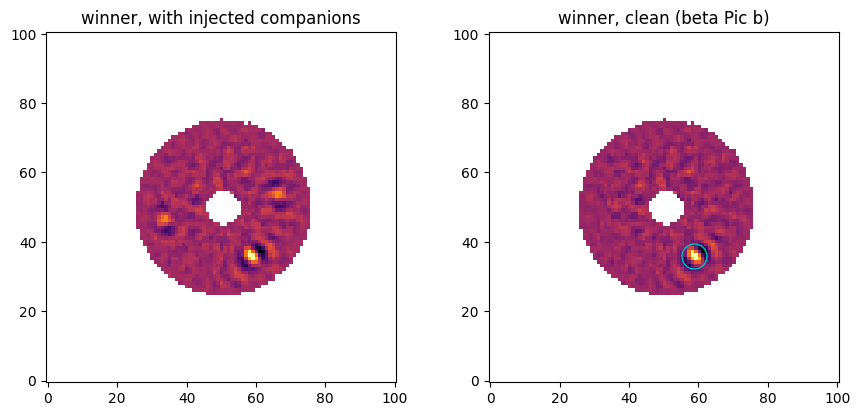

In [9]:
best_inj = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_inj.fits"))
best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, im, t in zip(ax, (best_inj, best_clean), ("winner, with injected companions", "winner, clean (beta Pic b)")):
    a.imshow(im, origin="lower", cmap="inferno"); a.set_title(t)
ax[1].plot(xb, yb, "o", mfc="none", mec="c", ms=18); plt.tight_layout()

In [10]:
metric = objective.metric          # carries known=[(0.452, 211.9)]; a metric built without it
                                   # would count beta Pic b as noise in its own ring
def bpic(im):
    return float(metric.per_source(im, None, [0.452], [211.9])[0])

print(f"injected companions: S/N ~5 (calibrated default)  ->  {r.winner_score:.1f} (validated winner)")
print(f"beta Pic b:          S/N {bpic(res.image):.1f} (default)  ->  {bpic(best_clean):.1f} (validated winner)")
print("\nbeta Pic b under each validated candidate -- configurations the objective rates as "
      "near-equal:")
for row in r.validation_table:
    p = dict(space.decode(np.asarray(row["x"], float)).params, inrad=8, outrad=22)
    img = red.reduce(ReductionRequest(params=p)).image
    print(f"   eval {row['eval_index'] + 1:4d}: validated {row['validated_score']:5.2f}   "
          f"beta Pic b {bpic(img):5.1f}")

injected companions: S/N ~5 (calibrated default)  ->  8.9 (validated winner)
beta Pic b:          S/N 15.6 (default)  ->  12.6 (validated winner)

beta Pic b under each validated candidate -- configurations the objective rates as near-equal:
   eval  278: validated  7.71   beta Pic b  12.6
   eval  196: validated  7.40   beta Pic b  12.1


   eval  147: validated  8.47   beta Pic b  12.3
   eval   99: validated  8.11   beta Pic b  11.4
   eval  186: validated  7.35   beta Pic b  12.3


   eval  276: validated  8.92   beta Pic b  12.6


The gain on the *injections* (≈5 → 9) is larger than on the planet (16 → 19): the
injections sit near the detection limit, where the parameters matter most, while β Pic b
is far above it.  To tune for a bright known companion, force the injection contrast to
its own with `CalibrationConfig(forced=[c])`.

Contrast curve (5σ, injection-calibrated throughput) of the validated winner, plus the
KLIP forward-model cross-check.  Known companions passed as `known=` are excluded from
the noise rings, so β Pic b does not inflate its own detection limit:

Text(0.5, 1.0, "beta Pic, NACO L'")

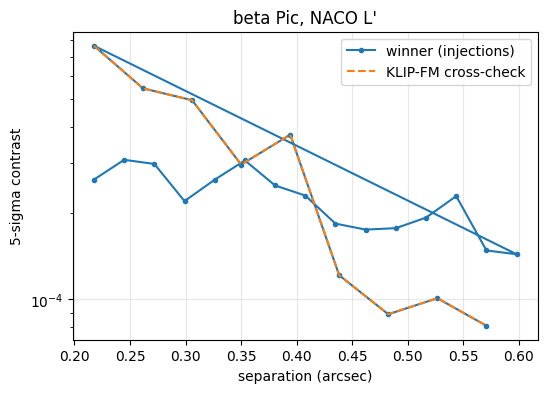

In [11]:
cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3, label="winner (injections)")
if r.fm_curve:
    plt.semilogy(r.fm_curve["r_as"], r.fm_curve["curve"], "--", label="KLIP-FM cross-check")
plt.xlabel("separation (arcsec)"); plt.ylabel("5-sigma contrast"); plt.legend(); plt.grid(alpha=.3); plt.title("beta Pic, NACO L'")

Everything else lives in the run directory — the step frames and movie, and the books:

| file | content |
|---|---|
| `steps/stepNNNN.png`, `annulus01/progress.gif`, `opt_steps.gif` | the live panel per evaluation and the movie |
| `annulus01/corner.pdf`, `landscapes.pdf` | the sampled parameter space, coloured by S/N |
| `annulus01/importance.pdf`, `paracoord.pdf`, `rank.pdf`, `slice.pdf` | which parameters matter |
| `annulus01/products.pdf`, `verify_limits.pdf`, `verify_subsets_inj.pdf` | winner images, S/N maps, detection limits |
| `annulus01/validation_panel.png`, `calibration_panel.png` | the validation and calibration stages |
| `klip_stitched*.fits`, `contrast_curve.txt`, `results.txt` | final images and tables |

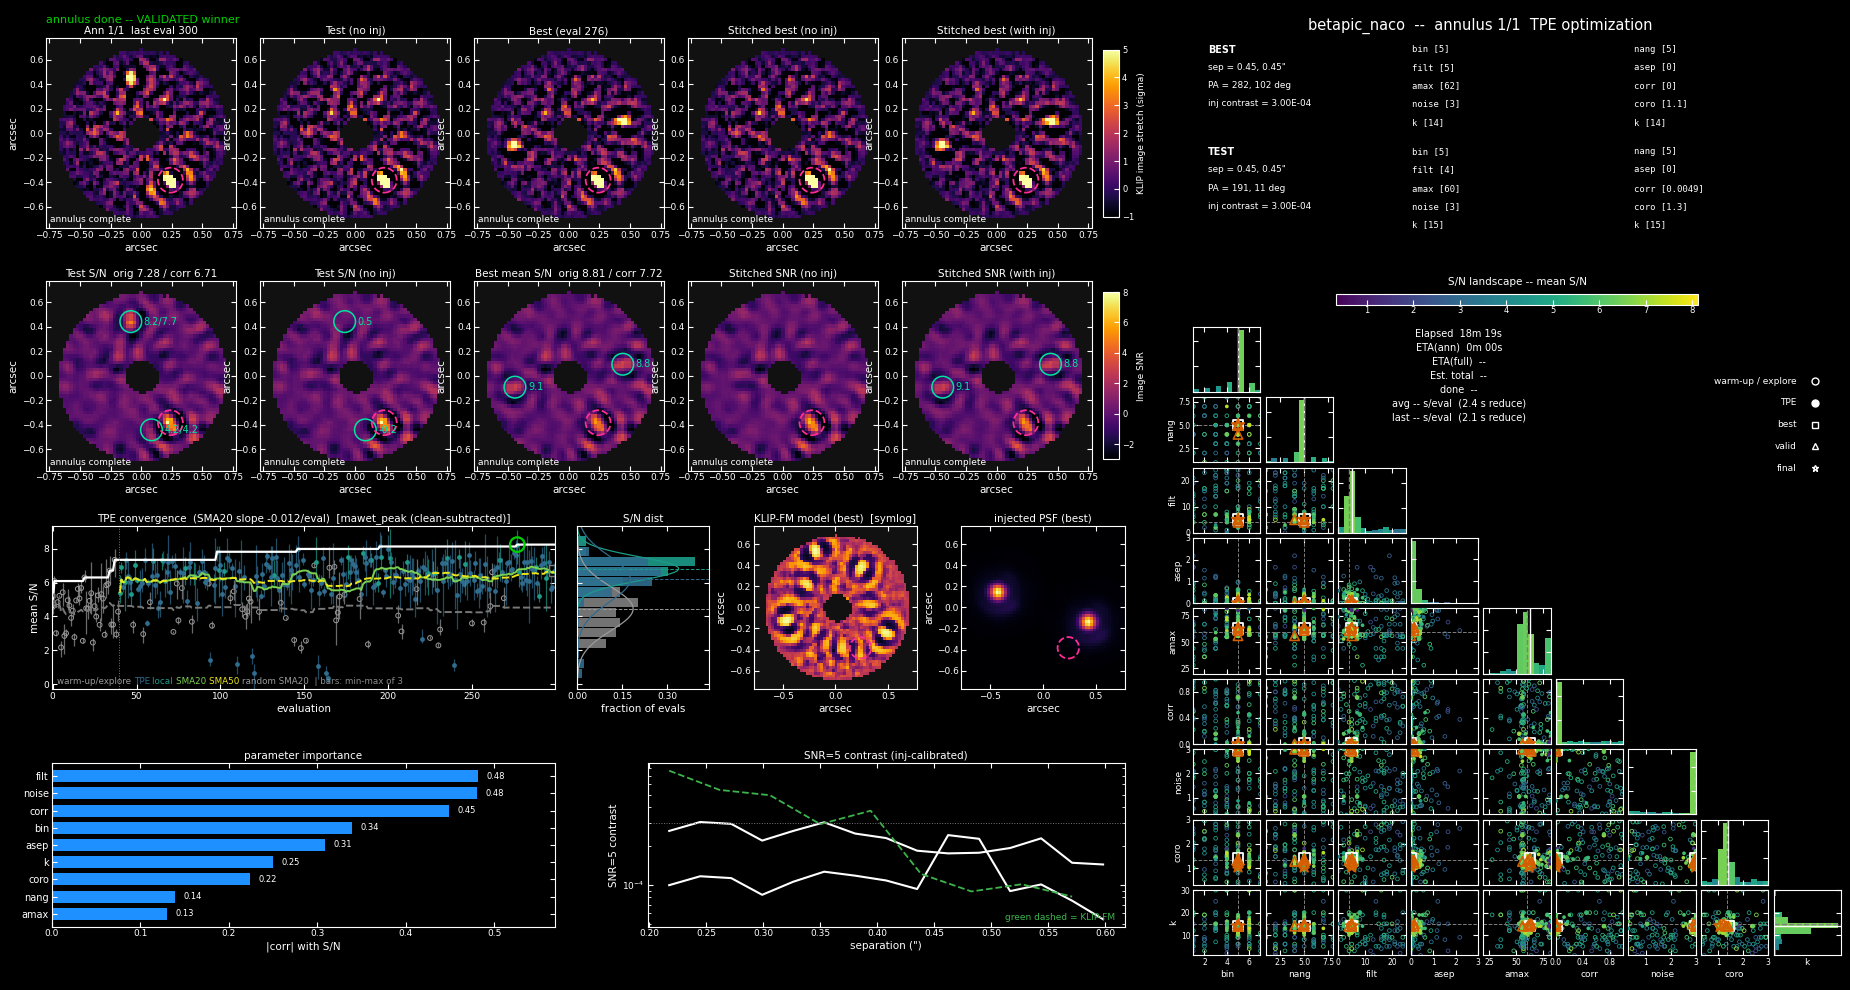

In [12]:
from IPython.display import Image
last_frame = sorted(f for f in os.listdir(os.path.join(RUN_DIR, "steps")) if f.startswith("step"))[-1]
Image(filename=os.path.join(RUN_DIR, "steps", last_frame), width=1000)     # the annulus-end frame

In [13]:
sorted(os.listdir(os.path.join(RUN_DIR, "annulus01")))[:40]

['best_clean.fits',
 'best_clean_partitions.fits',
 'best_fm.fits',
 'best_inj.fits',
 'best_inj_partitions.fits',
 'calib0001_setup.txt',
 'calib0002_setup.txt',
 'calibration.json',
 'calibration_panel.png',
 'contrast_curve.txt',
 'corner.pdf',
 'edf.png',
 'eval0001_setup.txt',
 'eval0002_setup.txt',
 'eval0003_setup.txt',
 'eval0004_setup.txt',
 'eval0005_setup.txt',
 'eval0006_setup.txt',
 'eval0007_setup.txt',
 'eval0008_setup.txt',
 'eval0009_setup.txt',
 'eval0010_setup.txt',
 'eval0011_setup.txt',
 'eval0012_setup.txt',
 'eval0013_setup.txt',
 'eval0014_setup.txt',
 'eval0015_setup.txt',
 'eval0016_setup.txt',
 'eval0017_setup.txt',
 'eval0018_setup.txt',
 'eval0019_setup.txt',
 'eval0020_setup.txt',
 'eval0021_setup.txt',
 'eval0022_setup.txt',
 'eval0023_setup.txt',
 'eval0024_setup.txt',
 'eval0025_setup.txt',
 'eval0026_setup.txt',
 'eval0027_setup.txt',
 'eval0028_setup.txt']

## 6. Other PSF-subtraction engines: VIP and pyKLIP

The optimizer does not care who subtracts the PSF.  `backend="vip"` (VIP's
`pca_annular`) or `backend="pyklip"` (`klip_parallelized`) replace the KLIP core and keep
the injection, frame selection, filtering, binning and scoring — so the same search space
can be compared across engines on the same data.  A single reduction each:

In [14]:
for backend in ("klip", "vip", "pyklip"):
    try:
        red_b = generic.make_reducer({"betapic": ds}, star_flux=star_flux, backend=backend, log=lambda s: None, **inst)
    except Exception as exc:                      # engine not installed
        print(f"{backend}: {exc}"); continue
    t = time.time()
    img = red_b.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=30, k_klip=10))).image
    print(f"{backend:7s} {time.time() - t:5.1f} s   peak {np.nanmax(img):.1f} at {np.unravel_index(np.nanargmax(np.nan_to_num(img, nan=-1e9)), img.shape)[::-1]}")

klip      0.1 s   peak 14.5 at (np.int64(58), np.int64(36))


vip       1.8 s   peak 42.3 at (np.int64(59), np.int64(36))


pyklip    0.2 s   peak 38.4 at (np.int64(58), np.int64(36))


To optimize with another engine, build the reducer with `backend=` and run exactly the
same cells (`Runner(...)`), e.g. `RUN_DIR + "_vip"`.  Note that KLIP-FM (the forward-model
cross-check curve) exists only for the built-in engine.

## 7. The same from a terminal

```
klip-tpe generic --cube naco_betapic_cube_cen.fits --angles naco_betapic_derot_angles.fits \
    --psf naco_betapic_psf.fits --star-flux 3.3268e6 --pxscale 0.02719 --lam 3.8e-6 --diam 8.2 \
    --known 0.452 211.9 --ann-edges 8 22 --n-iter 300 --n-init 40 --n-top 6 --n-valid 8 \
    --run-dir runs/betapic_cli --show           # --show opens the live window; --backend vip|pyklip
klip-tpe resume --run-dir runs/betapic_cli      # after an interruption
klip-tpe plots  --run-dir runs/betapic_cli      # regenerate the figures
```

## 8. Your own data

Anything registered on the star works: `generic.load_cube(cube, angles, psf=...,
ref_cube=...)` accepts arrays or FITS paths (a 4-d IFS cube with `wv_index=`), several
`Dataset`s (nights, epochs, IRDIS channels, pyNOMIC image groups …) become *partitions*
that the optimizer tunes and selects individually, and `ref_cube` switches on RDI/ARDI.
For pyNOMIC reductions use the dedicated adapter (`klip-tpe near --instrument nomic`);
for JWST see tutorial 3.